In [1]:
import os
import scipy.io as sio
import numpy as np

# Set the base dataset path
base_path = "./dropbox/Chair"  # change to Bag if needed

# List all folders in the dataset
folders = [f for f in os.listdir(base_path) if os.path.isdir(os.path.join(base_path, f))]
print("Folders in dataset:", folders)

Folders in dataset: ['syms', 'labels', 'models', 'part mesh indices', 'obbs', 'ops', 'boxes']


In [2]:
# Pick a sample file from the ops folder
ops_folder = os.path.join(base_path, "ops")
sample_file = os.listdir(ops_folder)[0]  # take the first file

# Load the .mat file
ops_data = sio.loadmat(os.path.join(ops_folder, sample_file))
ops_array = ops_data['op'].flatten()  # flatten to 1D

print("Sample file:", sample_file)
print("Ops array (node types):", ops_array)
print("Number of nodes:", len(ops_array))

Sample file: 259.mat
Ops array (node types): [0 0 0 1 2 1 0 0 1 2 0 0 2 1 1 1]
Number of nodes: 16


In [3]:
# Load the corresponding part mesh indices file
part_mesh_folder = os.path.join(base_path, "part mesh indices")
part_mesh_file = os.path.join(part_mesh_folder, sample_file)  # same filename

part_mesh_data = sio.loadmat(part_mesh_file)
part_mesh_indices = part_mesh_data['cell_boxs_correspond_objSerialNumber']

# Convert to a Python-friendly list
part_mesh_list = []
for item in part_mesh_indices[0]:
    # Each item can be an array of indices
    indices = item.flatten().tolist()
    part_mesh_list.append(indices)

print("Part mesh indices for leaf nodes:", part_mesh_list)

Part mesh indices for leaf nodes: [[8], [10], [12, 13], [6], [5], [7], [4]]


In [4]:
# Load the labels file
labels_folder = os.path.join(base_path, "labels")
labels_file = os.path.join(labels_folder, sample_file)

labels_data = sio.loadmat(labels_file)
labels_array = labels_data['label'].flatten()

print("Semantic labels for leaf nodes:", labels_array)

Semantic labels for leaf nodes: [1 2 2 0 0 0 0]


In [5]:
# Load the symmetry parameters
syms_folder = os.path.join(base_path, "syms")
syms_file = os.path.join(syms_folder, sample_file)

syms_data = sio.loadmat(syms_file)
sym_params = syms_data['sym']

print("Symmetry parameters shape:", sym_params.shape)
print("Symmetry parameters:\n", sym_params)

Symmetry parameters shape: (8, 3)
Symmetry parameters:
 [[ 0.00000e+00  0.00000e+00  0.00000e+00]
 [ 9.99993e-01  9.99115e-01  9.99793e-01]
 [-2.82856e-03 -1.64490e-02  1.95908e-02]
 [ 2.42270e-03  3.87166e-02  5.48454e-03]
 [ 9.38500e-04  8.81475e-03 -8.33500e-04]
 [-3.43145e-01  4.50852e-01  4.36789e-01]
 [-3.36696e-01 -3.35758e-01 -3.45313e-01]
 [ 0.00000e+00  0.00000e+00  0.00000e+00]]


In [6]:
# Load the bounding boxes
boxes_folder = os.path.join(base_path, "boxes")
boxes_file = os.path.join(boxes_folder, sample_file)

boxes_data = sio.loadmat(boxes_file)
boxes_array = boxes_data['box']

print("Bounding boxes shape:", boxes_array.shape)
print("Bounding boxes (first 3 nodes):\n", boxes_array[:, :3])

Bounding boxes shape: (12, 7)
Bounding boxes (first 3 nodes):
 [[ 6.16500e-04 -3.00891e-01 -3.00891e-01]
 [ 2.35650e-02 -3.42292e-01 -3.42292e-01]
 [ 7.86515e-02 -3.37427e-01  5.04667e-01]
 [ 1.26728e-01  6.60743e-01  6.60743e-01]
 [ 1.00499e+00  1.69626e-01  1.50088e-01]
 [ 7.44767e-01  1.38543e-01  1.38543e-01]
 [ 0.00000e+00  0.00000e+00  0.00000e+00]
 [ 1.00000e+00  1.00000e+00  1.00000e+00]
 [ 0.00000e+00  0.00000e+00  0.00000e+00]
 [ 0.00000e+00  0.00000e+00  0.00000e+00]
 [ 0.00000e+00  0.00000e+00  0.00000e+00]
 [ 1.00000e+00  1.00000e+00  1.00000e+00]]


In [7]:
# Load an example .obj mesh file for the first leaf node
import trimesh

models_folder = os.path.join(base_path, "models")
mesh_file = os.path.join(models_folder, f"{part_mesh_list[0][0]}.obj")  # first leaf node

mesh = trimesh.load(mesh_file)
print(mesh)
print("Vertices shape:", mesh.vertices.shape)
print("Faces shape:", mesh.faces.shape)

ValueError: string is not a file: `./dropbox/Chair/models/8.obj`

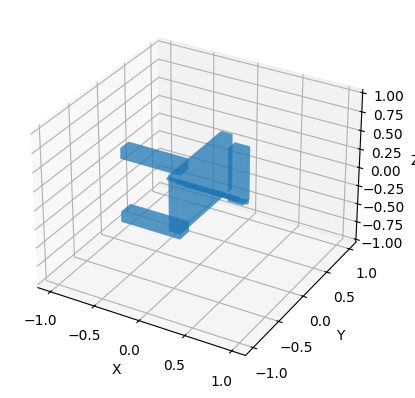

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

def create_box_vertices(center, size):
    """Generate the 8 vertices of a 3D box from center and size (w,h,d)."""
    w, h, d = size / 2
    cx, cy, cz = center
    # Vertices of a cube centered at origin
    vertices = np.array([
        [ cx - w, cy - h, cz - d],
        [ cx + w, cy - h, cz - d],
        [ cx + w, cy + h, cz - d],
        [ cx - w, cy + h, cz - d],
        [ cx - w, cy - h, cz + d],
        [ cx + w, cy - h, cz + d],
        [ cx + w, cy + h, cz + d],
        [ cx - w, cy + h, cz + d],
    ])
    return vertices

# Plot all boxes
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

num_leaf_nodes = boxes_array.shape[1]

for i in range(num_leaf_nodes):
    center = boxes_array[0:3, i]
    size = boxes_array[3:6, i]
    verts = create_box_vertices(center, size)
    # Define the 6 faces of the box
    faces = [
        [verts[j] for j in [0,1,2,3]],
        [verts[j] for j in [4,5,6,7]],
        [verts[j] for j in [0,1,5,4]],
        [verts[j] for j in [2,3,7,6]],
        [verts[j] for j in [1,2,6,5]],
        [verts[j] for j in [4,7,3,0]],
    ]
    ax.add_collection3d(Poly3DCollection(faces, alpha=0.5))

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.auto_scale_xyz([-1,1], [-1,1], [-1,1])
plt.show()

In [8]:
import k3d
from itertools import product, combinations

# Map labels to colors (chair example)
label_colors = {
    0: 0xff0000,  # back - red
    1: 0x00ff00,  # seat - green
    2: 0x0000ff,  # leg - blue
    3: 0xffff00,  # armrest - yellow
}

# Function to generate vertices for a box
def create_box_vertices(center, size):
    w, h, d = size / 2
    cx, cy, cz = center
    # 8 vertices of the box
    return np.array(list(product([cx-w, cx+w], [cy-h, cy+h], [cz-d, cz+d])))

# Function to create box faces from vertices
def create_box_faces(vertices):
    # 12 triangles (2 per face)
    faces = [
        [0,1,2],[0,2,3],  # bottom
        [4,5,6],[4,6,7],  # top
        [0,1,5],[0,5,4],  # front
        [2,3,7],[2,7,6],  # back
        [1,2,6],[1,6,5],  # right
        [0,3,7],[0,7,4]   # left
    ]
    return faces

# Create K3D plot
plot = k3d.plot()
for i in range(boxes_array.shape[1]):
    center = boxes_array[0:3, i]
    size = boxes_array[3:6, i]
    verts = create_box_vertices(center, size)
    faces = create_box_faces(verts)
    faces_flat = np.array(faces, dtype=np.uint32).flatten()
    vertices_flat = verts.astype(np.float32)
    color = label_colors.get(labels_array[i], 0xffffff)
    mesh = k3d.mesh(vertices_flat, faces_flat, color=color, opacity=0.5)
    plot += mesh

plot.display()

Output()

In [9]:
import k3d

# Function to create the 12 edges of a cuboid from its center and size
def create_box_edges(center, size):
    w, h, d = size / 2
    cx, cy, cz = center
    # 8 vertices
    vertices = np.array(list(product([cx-w, cx+w], [cy-h, cy+h], [cz-d, cz+d])))
    # Edges as vertex index pairs
    edges_idx = [
        [0,1],[1,3],[3,2],[2,0],  # bottom
        [4,5],[5,7],[7,6],[6,4],  # top
        [0,4],[1,5],[2,6],[3,7]   # verticals
    ]
    return vertices, edges_idx

# Create K3D plot
plot = k3d.plot()
for i in range(boxes_array.shape[1]):
    center = boxes_array[0:3, i]
    size = boxes_array[3:6, i]
    vertices, edges_idx = create_box_edges(center, size)
    # Flatten vertices and connect edges
    for edge in edges_idx:
        line = k3d.line(vertices[edge], shader='3d', color=label_colors.get(labels_array[i], 0xffffff), width=0.02)
        plot += line

plot.display()

/opt/homebrew/Caskroom/miniconda/base/envs/abs/lib/python3.12/site-packages/traittypes/traittypes.py:97: UserWarning: Given trait value dtype "float64" does not match required type "float32". A coerced copy has been created.
  warnings.warn(


Output()

In [10]:
def apply_rotation(vertices, rotation):
    """Rotate vertices by a 3x3 rotation matrix."""
    return vertices @ rotation.T

plot = k3d.plot()
for i in range(boxes_array.shape[1]):
    center = boxes_array[0:3, i]
    size = boxes_array[3:6, i]

    # Rotation matrix from rows 6-11 of box (assuming 3x3)
    rotation = boxes_array[6:9, i].reshape(3, 1) * 0  # placeholder
    # For now, if rotation is identity
    rotation = np.eye(3)

    # Create cuboid vertices
    vertices = np.array(list(product([-0.5,0.5], [-0.5,0.5], [-0.5,0.5])))
    vertices *= size  # scale
    vertices = apply_rotation(vertices, rotation)
    vertices += center  # translate

    # Define edges
    edges_idx = [
        [0,1],[1,3],[3,2],[2,0],
        [4,5],[5,7],[7,6],[6,4],
        [0,4],[1,5],[2,6],[3,7]
    ]

    for edge in edges_idx:
        line = k3d.line(vertices[edge], shader='3d', color=label_colors.get(labels_array[i], 0xffffff), width=0.02)
        plot += line

plot.display()

Output()

In [11]:
def create_oriented_box(center, size, rotation_axes):
    """
    center: 3-vector
    size: 3-vector (lengths along each local axis)
    rotation_axes: 3x3 matrix where each column is a local axis
    """
    # Vertices of unit cube [-0.5, 0.5]^3
    vertices = np.array(list(product([-0.5,0.5], [-0.5,0.5], [-0.5,0.5])))
    vertices *= size  # scale by box size
    vertices = vertices @ rotation_axes.T  # apply rotation
    vertices += center  # translate to center
    return vertices

plot = k3d.plot()

for i in range(boxes_array.shape[1]):
    center = boxes_array[0:3, i]
    size = boxes_array[3:6, i]

    # Rotation axes from rows 6-11
    rotation_axes = np.column_stack((boxes_array[6:9,i], boxes_array[9:12,i], np.cross(boxes_array[6:9,i], boxes_array[9:12,i])))
    
    vertices = create_oriented_box(center, size, rotation_axes)

    # Define edges
    edges_idx = [
        [0,1],[1,3],[3,2],[2,0],
        [4,5],[5,7],[7,6],[6,4],
        [0,4],[1,5],[2,6],[3,7]
    ]

    for edge in edges_idx:
        line = k3d.line(vertices[edge], shader='3d', color=label_colors.get(labels_array[i], 0xffffff), width=0.02)
        plot += line

plot.display()

Output()

In [12]:
plot = k3d.plot()

# ops array: 0 = leaf, 1 = adjacency, 2 = symmetry
ops_array = ops_array  # from your loaded file
boxes = boxes_array
labels = labels_array
sym_params_array = sym_params  # shape (8,3)

# Build list of leaf nodes
leaf_indices = [i for i, v in enumerate(ops_array) if v == 0]

# Track which leaf nodes belong to which symmetry node
# For simplicity, assume the ordering in ops matches sym_params
symmetry_nodes = [i for i, v in enumerate(ops_array) if v == 2]

def apply_symmetry(center, sym_param):
    """
    Apply symmetry transformation to a center.
    For simplicity, treat sym_param as translation (real implementation may include rotation/reflection)
    """
    return center + sym_param  # placeholder; can refine if we know actual sym type

# Plot each leaf node
leaf_idx_counter = 0
for i, op in enumerate(ops_array):
    if op == 0:  # leaf node
        center = boxes[0:3, leaf_idx_counter]
        size = boxes[3:6, leaf_idx_counter]

        # Identity rotation for now
        rotation_axes = np.column_stack((boxes[6:9, leaf_idx_counter],
                                         boxes[9:12, leaf_idx_counter],
                                         np.cross(boxes[6:9, leaf_idx_counter],
                                                  boxes[9:12, leaf_idx_counter])))
        # Original cuboid
        vertices = create_oriented_box(center, size, rotation_axes)
        edges_idx = [
            [0,1],[1,3],[3,2],[2,0],
            [4,5],[5,7],[7,6],[6,4],
            [0,4],[1,5],[2,6],[3,7]
        ]
        for edge in edges_idx:
            line = k3d.line(vertices[edge], shader='3d', color=label_colors.get(labels[leaf_idx_counter], 0xffffff), width=0.02)
            plot += line

        leaf_idx_counter += 1

    elif op == 2:  # symmetry node
        # Apply symmetry to following leaf nodes (simplified)
        sym_param = sym_params_array[i % sym_params_array.shape[0]]  # pick corresponding row
        # replicate last leaf node
        last_center = boxes[0:3, leaf_idx_counter - 1]
        last_size = boxes[3:6, leaf_idx_counter - 1]
        rotation_axes = np.column_stack((boxes[6:9, leaf_idx_counter - 1],
                                         boxes[9:12, leaf_idx_counter - 1],
                                         np.cross(boxes[6:9, leaf_idx_counter - 1],
                                                  boxes[9:12, leaf_idx_counter - 1])))
        new_center = apply_symmetry(last_center, sym_param)
        vertices = create_oriented_box(new_center, last_size, rotation_axes)
        for edge in edges_idx:
            line = k3d.line(vertices[edge], shader='3d', color=0xff0000, width=0.02)
            plot += line

plot.display()

Output()

In [13]:
import numpy as np
import k3d

plot = k3d.plot()

# Example label colors
label_colors = {0: 0x00ff00, 1: 0x0000ff, 2: 0xffff00, 3: 0xff00ff}

# Helper: create cuboid vertices from center, size, rotation axes
def create_oriented_box(center, size, axes):
    cx, cy, cz = center
    sx, sy, sz = size / 2  # half-size
    # Create 8 corners in local frame
    corners = np.array([
        [-sx, -sy, -sz],
        [-sx, -sy, sz],
        [-sx, sy, -sz],
        [-sx, sy, sz],
        [sx, -sy, -sz],
        [sx, -sy, sz],
        [sx, sy, -sz],
        [sx, sy, sz]
    ])
    # Apply rotation axes
    rot_mat = axes
    vertices = corners @ rot_mat.T
    vertices += center
    return vertices

# Simplified symmetry: apply translation/reflection from sym param
def apply_symmetry(center, sym_param):
    return center + sym_param  # placeholder; refine for rotation if known

# DFS traversal to collect leaf node boxes with symmetry
def traverse_ops(ops, boxes, sym_params, start_idx=0):
    nodes = []
    stack = [(start_idx, np.eye(3), np.zeros(3))]  # (index, rotation, translation)
    leaf_counter = 0
    sym_counter = 0

    while stack:
        idx, rot, trans = stack.pop()
        op_type = ops[idx]

        if op_type == 0:  # leaf node
            center = boxes[0:3, leaf_counter]
            size = boxes[3:6, leaf_counter]
            axes = np.column_stack((boxes[6:9, leaf_counter],
                                    boxes[9:12, leaf_counter],
                                    np.cross(boxes[6:9, leaf_counter],
                                             boxes[9:12, leaf_counter])))
            # Apply current transform
            transformed_center = rot @ center + trans
            transformed_axes = rot @ axes
            nodes.append((transformed_center, size, transformed_axes))
            leaf_counter += 1

        elif op_type == 2:  # symmetry node
            sym = sym_params[sym_counter % sym_params.shape[0]]
            new_trans = trans + sym  # apply translation/reflection
            sym_counter += 1
            # Push the next child (immediately after) onto stack with new transform
            # Simplified: only one child for demo
            if idx + 1 < len(ops):
                stack.append((idx + 1, rot, new_trans))
        # adjacency nodes (1) are skipped for visualization

    return nodes

# Get all transformed leaf nodes
leaf_nodes = traverse_ops(ops_array, boxes_array, sym_params)

# Draw cuboids
edges_idx = [
    [0,1],[1,3],[3,2],[2,0],
    [4,5],[5,7],[7,6],[6,4],
    [0,4],[1,5],[2,6],[3,7]
]

for i, (center, size, axes) in enumerate(leaf_nodes):
    vertices = create_oriented_box(center, size, axes)
    for edge in edges_idx:
        line = k3d.line(vertices[edge], shader='3d', color=0x00ff00, width=0.02)
        plot += line

plot.display()

Output()